In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt

In [4]:
sns.set_theme(style="whitegrid")
data = pd.read_csv('./data/raw-data/customer_shopping_data.csv')

In [10]:
data.shape

(99457, 10)

In [9]:
data.tail(10)

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
99447,I281214,C288090,Female,37,Toys,3,107.52,Cash,21/02/2021,Metropol AVM
99448,I332105,C231387,Female,65,Shoes,4,2400.68,Credit Card,29/08/2021,Metropol AVM
99449,I134399,C953724,Male,65,Clothing,1,300.08,Cash,1/1/2023,Kanyon
99450,I170504,C226974,Female,28,Books,1,15.15,Cash,28/02/2023,Zorlu Center
99451,I675411,C513603,Male,50,Toys,5,179.20,Cash,9/10/2021,Metropol AVM
99452,I219422,C441542,Female,45,Souvenir,5,58.65,Credit Card,21/09/2022,Kanyon
99453,I325143,C569580,Male,27,Food & Beverage,2,10.46,Cash,22/09/2021,Forum Istanbul
99454,I824010,C103292,Male,63,Food & Beverage,2,10.46,Debit Card,28/03/2021,Metrocity
99455,I702964,C800631,Male,56,Technology,4,4200.00,Cash,16/03/2021,Istinye Park
99456,I232867,C273973,Female,36,Souvenir,3,35.19,Credit Card,15/10/2022,Mall of Istanbul


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  str    
 1   customer_id     99457 non-null  str    
 2   gender          99457 non-null  str    
 3   age             99457 non-null  int64  
 4   category        99457 non-null  str    
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  str    
 8   invoice_date    99457 non-null  str    
 9   shopping_mall   99457 non-null  str    
dtypes: float64(1), int64(2), str(7)
memory usage: 7.6 MB


In [11]:
# Check Missing Values
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "Không có dữ liệu rỗng.")

Không có dữ liệu rỗng.


In [13]:
# Check Duplicate
duplicates = data.duplicated().sum()
print(duplicates)

0


In [18]:
invalid_age = data[(data['age'] < 0) | (data['age'] > 100)]
print(f"Số lượng khách hàng có số tuổi vô lý (<0 hoặc >100): {len(invalid_age)} dòng")

Số lượng khách hàng có số tuổi vô lý (<0 hoặc >100): 0 dòng


In [19]:
invalid_quantity = data[data['quantity'] <= 0]
invalid_price = data[data['price'] <= 0]
print(f"Số lượng giao dịch có Quantity <= 0 (Có thể là đơn trả hàng): {len(invalid_quantity)} dòng")
print(f"Số lượng giao dịch có Price <= 0 (Lỗi nhập liệu): {len(invalid_price)} dòng")

Số lượng giao dịch có Quantity <= 0 (Có thể là đơn trả hàng): 0 dòng
Số lượng giao dịch có Price <= 0 (Lỗi nhập liệu): 0 dòng


In [20]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Cột '{col}': Phát hiện {len(outliers)} điểm ngoại lai (Outliers).")
    print(f"  + Ranh giới an toàn: [{lower_bound:.2f} -> {upper_bound:.2f}]")
    return outliers

In [21]:
outliers_quantity = detect_outliers_iqr(data, 'quantity')
outliers_price = detect_outliers_iqr(data, 'price')

Cột 'quantity': Phát hiện 0 điểm ngoại lai (Outliers).
  + Ranh giới an toàn: [-1.00 -> 7.00]
Cột 'price': Phát hiện 5024 điểm ngoại lai (Outliers).
  + Ranh giới an toàn: [-1686.85 -> 2932.62]


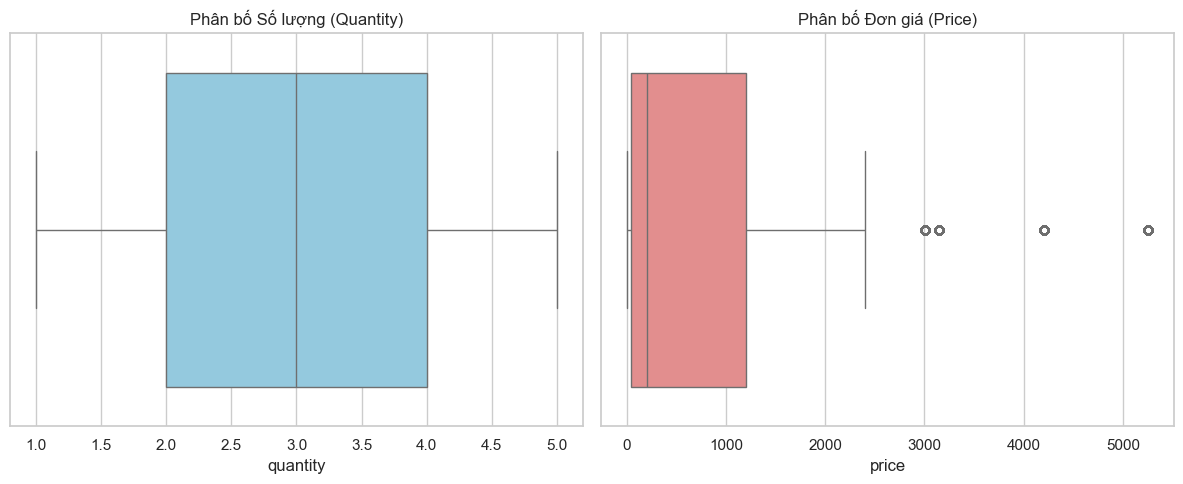

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x=data['quantity'], ax=axes[0], color='skyblue')
axes[0].set_title('Phân bố Số lượng (Quantity)')

sns.boxplot(x=data['price'], ax=axes[1], color='lightcoral')
axes[1].set_title('Phân bố Đơn giá (Price)')

plt.tight_layout()
plt.show()

C:\Users\minhchi\AppData\Local\Temp\ipykernel_24148\4134598264.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='price', y='shopping_mall', palette='Set2')


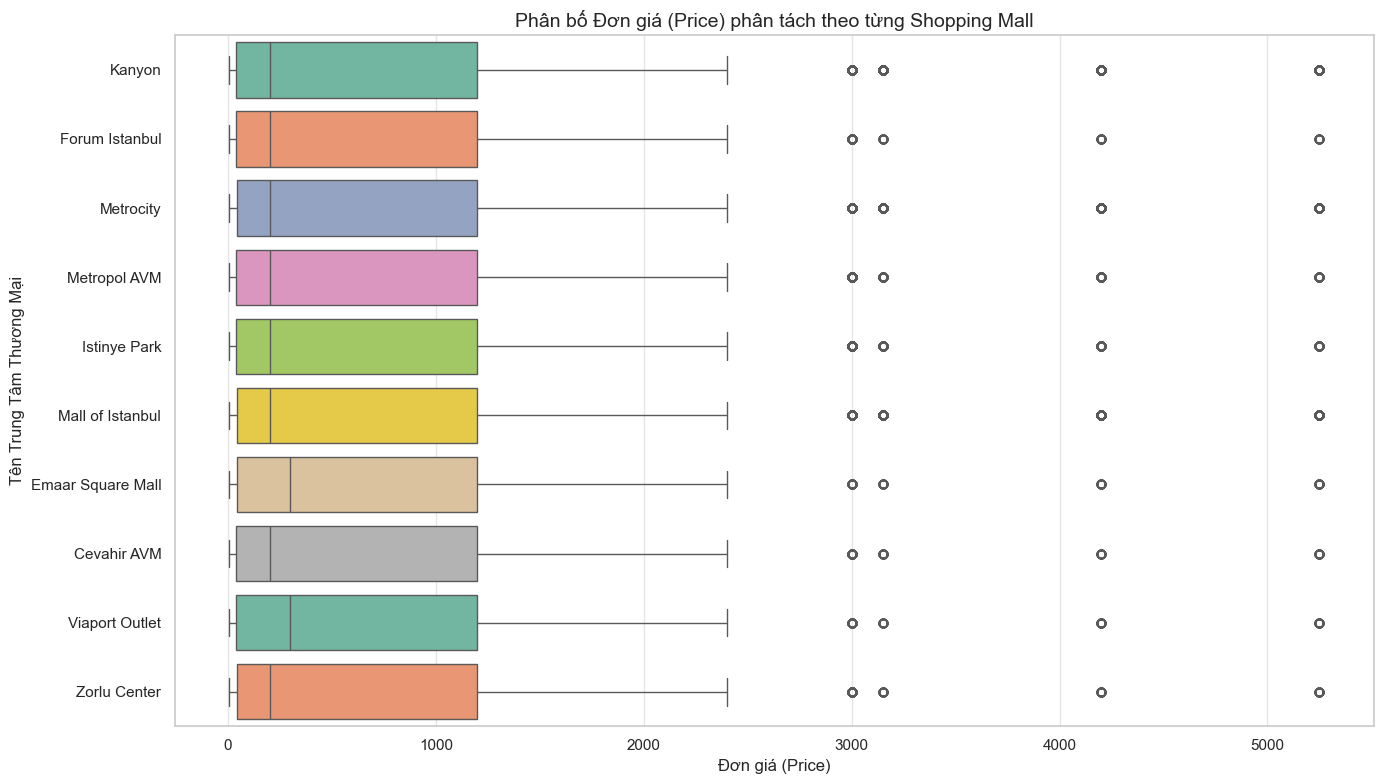

In [30]:
plt.figure(figsize=(14, 8))
# Vẽ Boxplot phân bố giá (Price) chia theo từng Shopping Mall
sns.boxplot(data=data, x='price', y='shopping_mall', palette='Set2')

plt.title('Phân bố Đơn giá (Price) phân tách theo từng Shopping Mall', fontsize=14)
plt.xlabel('Đơn giá (Price)', fontsize=12)
plt.ylabel('Tên Trung Tâm Thương Mại', fontsize=12)
plt.grid(True, alpha=0.5, axis='x')
plt.tight_layout()
plt.show()

In [23]:
for col in ['gender', 'category', 'payment_method', 'shopping_mall']:
    print(f"\n* Thống kê các giá trị trong cột '{col}':")
    # Đếm số lượng của từng hạng mục và in ra
    print(data[col].value_counts(dropna=False))


* Thống kê các giá trị trong cột 'gender':
gender
Female    59482
Male      39975
Name: count, dtype: int64

* Thống kê các giá trị trong cột 'category':
category
Clothing           34487
Cosmetics          15097
Food & Beverage    14776
Toys               10087
Shoes              10034
Souvenir            4999
Technology          4996
Books               4981
Name: count, dtype: int64

* Thống kê các giá trị trong cột 'payment_method':
payment_method
Cash           44447
Credit Card    34931
Debit Card     20079
Name: count, dtype: int64

* Thống kê các giá trị trong cột 'shopping_mall':
shopping_mall
Mall of Istanbul     19943
Kanyon               19823
Metrocity            15011
Metropol AVM         10161
Istinye Park          9781
Zorlu Center          5075
Cevahir AVM           4991
Forum Istanbul        4947
Viaport Outlet        4914
Emaar Square Mall     4811
Name: count, dtype: int64


In [24]:
# Analysis time feature
temp_df = data.copy()

# Ép kiểu chuỗi về Datetime
temp_df['invoice_date'] = pd.to_datetime(temp_df['invoice_date'], format='%d/%m/%Y')

# Trích xuất Năm-Tháng và Ngày trong tuần để phân tích
temp_df['YearMonth'] = temp_df['invoice_date'].dt.to_period('M')
temp_df['DayOfWeek'] = temp_df['invoice_date'].dt.day_name()

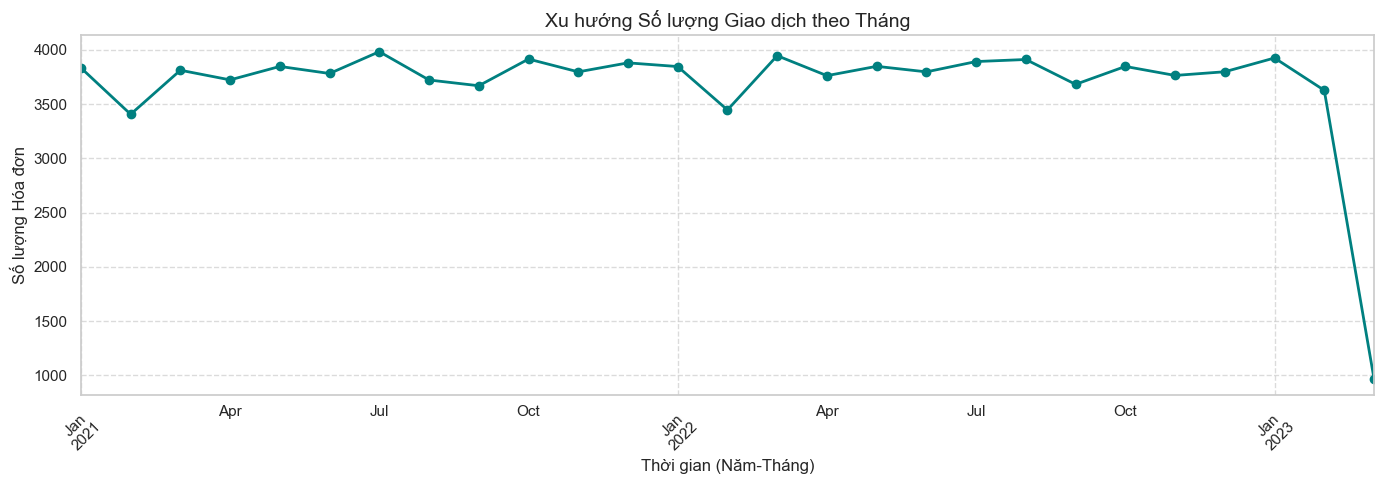

In [25]:
plt.figure(figsize=(14, 5))
# Đếm số lượng giao dịch theo từng tháng
monthly_transactions = temp_df.groupby('YearMonth').size()
monthly_transactions.plot(kind='line', marker='o', color='teal', linewidth=2)

plt.title('Xu hướng Số lượng Giao dịch theo Tháng', fontsize=14)
plt.xlabel('Thời gian (Năm-Tháng)', fontsize=12)
plt.ylabel('Số lượng Hóa đơn', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Xuyên suốt 2 năm 2021 và 2022, lượng hóa đơn hàng tháng dao động cực kỳ ổn định trong một biên độ hẹp (khoảng từ 3500 đến hơn 4000 giao dịch/tháng). Có những tháng hơi nhích lên (như giữa năm 2021 hoặc giữa năm 2022) và hơi đi xuống, nhưng nhìn chung đồ thị đi theo một đường khá "phẳng"
    
    -> Các trung tâm thương mại trong tập dữ liệu này duy trì được lượng khách hàng "ruột" rất tốt. Doanh số được tạo ra từ nhu cầu tiêu dùng thường xuyên thay vì phụ thuộc vào các đợt bùng nổ ngắn hạn
- Trong ngành bán lẻ thông thường, đồ thị sẽ luôn có những đỉnh chọc trời vào các tháng cuối năm (tháng 11, 12) do hiệu ứng Black Friday, Giáng Sinh. Tuy nhiên, trên biểu đồ này, các tháng cuối năm không hề có sự bứt phá nào quá khác biệt so với các tháng giữa năm

    -> Có thể thực hiện Feature Engineering với feature Month nhưng ko quá kỳ vọng do các regression model phải dựa nhiều hơn vào các biến như danh mục sản phẩm hay địa điểm mua sắm thay vì yếu tố tháng
- Nhìn vào điểm cuối cùng bên phải của đồ thị (khoảng tháng 3 năm 2023). Đồ thị đang đi ngang bỗng nhiên rơi tự do cắm thẳng xuống gần mốc 0. Đây không phải là do các trung tâm thương mại đồng loạt ế khách mà đây là hiện tượng dữ liệu được thu thập dở khiến tổng lượng giao dịch của tháng đó bị thiếu hụt nghiêm trọng

C:\Users\minhchi\AppData\Local\Temp\ipykernel_24148\1617104351.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=temp_df, x='DayOfWeek', order=day_order, palette='viridis')


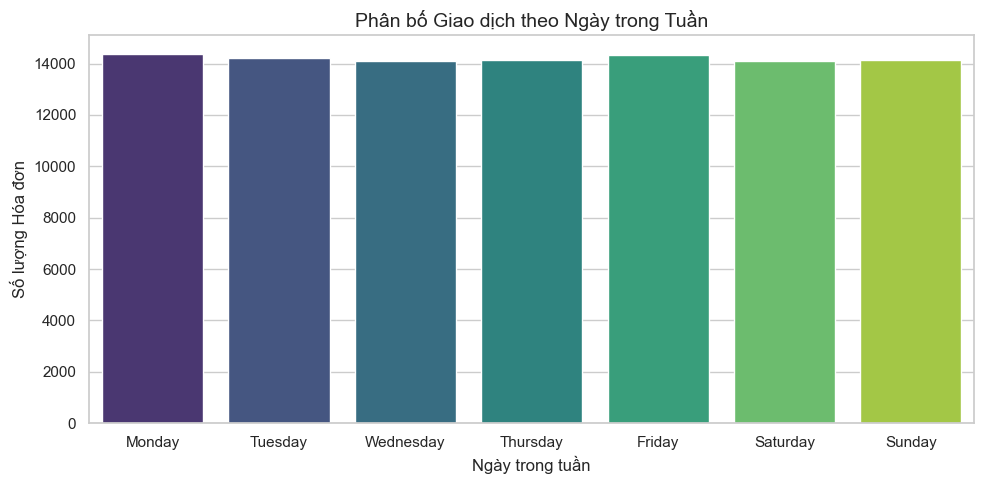

In [26]:
plt.figure(figsize=(10, 5))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=temp_df, x='DayOfWeek', order=day_order, palette='viridis')

plt.title('Phân bố Giao dịch theo Ngày trong Tuần', fontsize=14)
plt.xlabel('Ngày trong tuần', fontsize=12)
plt.ylabel('Số lượng Hóa đơn', fontsize=12)
plt.tight_layout()
plt.show()

In [27]:
# Tạo DataFrame đếm số lượng giao dịch theo Tháng và TTTM
monthly_mall = temp_df.groupby(['YearMonth', 'shopping_mall']).size().reset_index(name='Transaction_Count')
monthly_mall['YearMonth'] = monthly_mall['YearMonth'].astype(str) # Chuyển về chuỗi để dễ vẽ

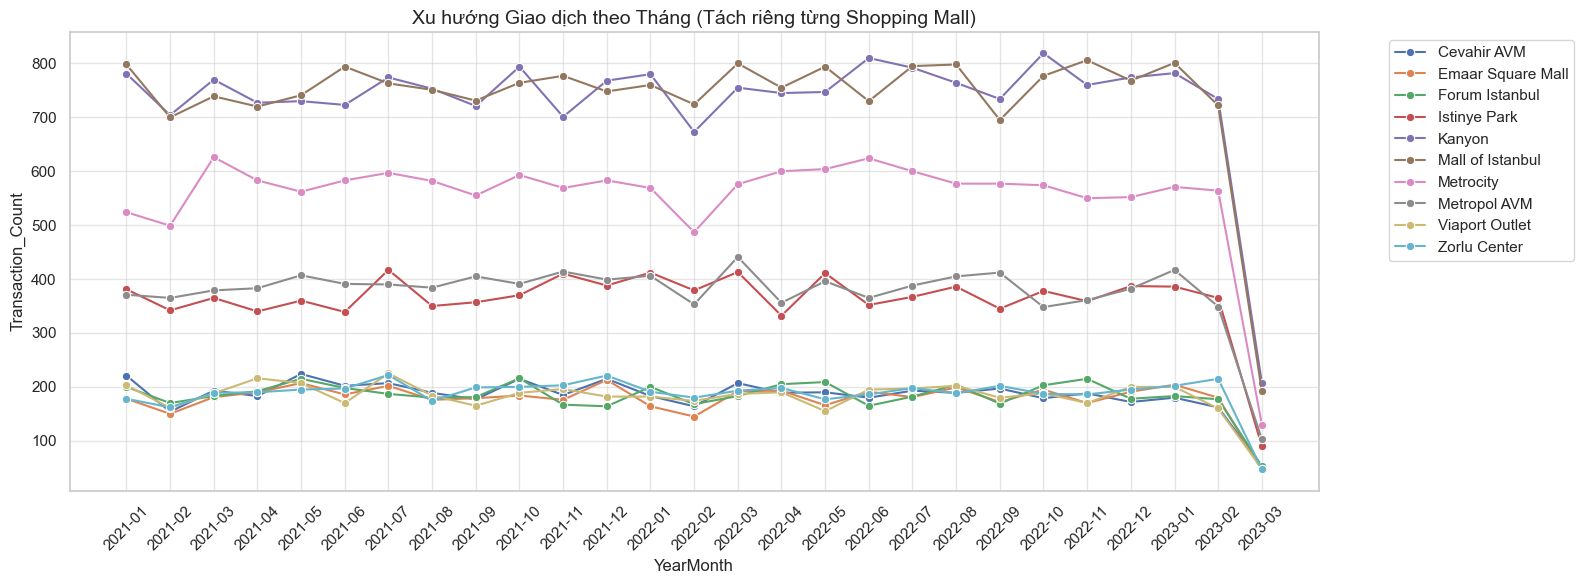

In [28]:
plt.figure(figsize=(16, 6))
sns.lineplot(data=monthly_mall, x='YearMonth', y='Transaction_Count', hue='shopping_mall', marker='o')
plt.title('Xu hướng Giao dịch theo Tháng (Tách riêng từng Shopping Mall)', fontsize=14)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

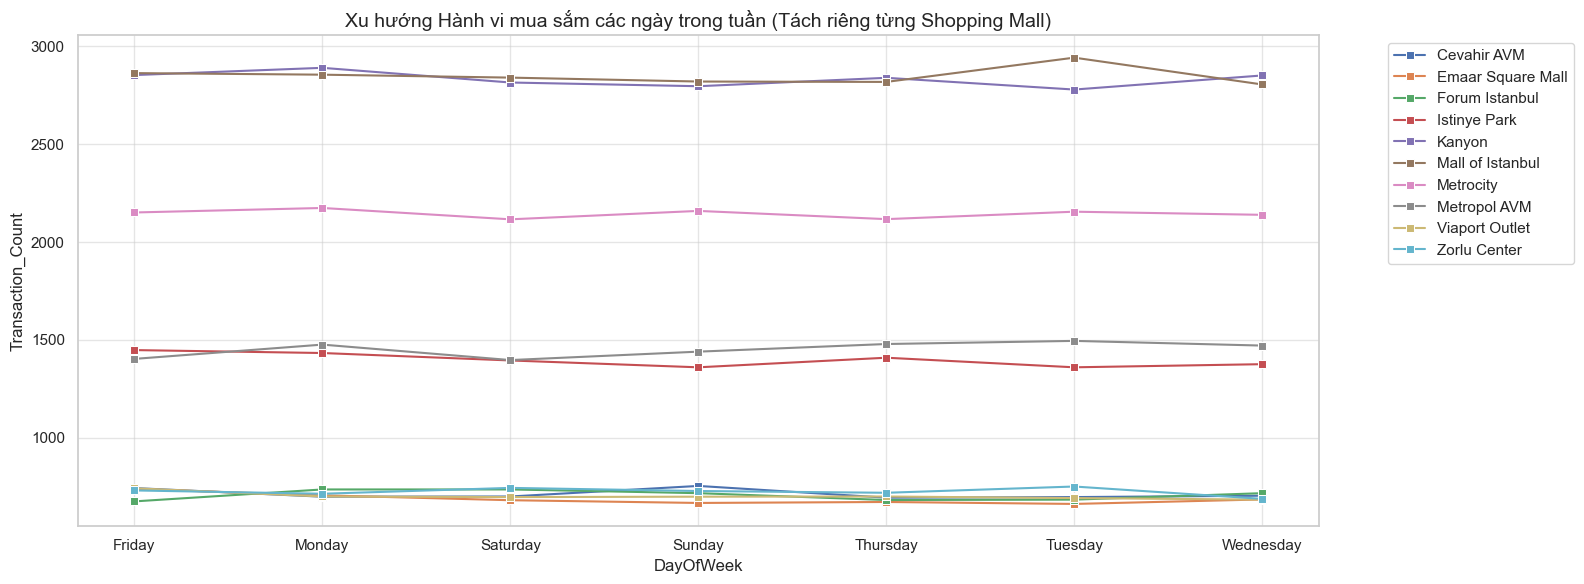

In [29]:
plt.figure(figsize=(16, 6))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# Dùng lineplot thay vì bar chart để 10 đường không bị rối mắt
daily_mall = temp_df.groupby(['DayOfWeek', 'shopping_mall']).size().reset_index(name='Transaction_Count')
sns.lineplot(data=daily_mall, x='DayOfWeek', y='Transaction_Count', hue='shopping_mall', marker='s', sort=False)
plt.title('Xu hướng Hành vi mua sắm các ngày trong tuần (Tách riêng từng Shopping Mall)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()